### This notebook script read pre-saved cell data from folder and visualize the CFD simulation.
### so that I can repeat same simulation using different visualization settings.

In [1]:
import torch
import os

from CFD import RadiativeTransfer
from CFD import AdvectingField
from CFD import create_sphere_mask

from JupyterVisualizer import ImageVisualizer

In [9]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
    
#this is where simulation results were saved.
folder_path = "/mnt/storage/cells/"
params = torch.load("/mnt/storage/params.pt")

#Get file names ready
file_names = sorted([
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f)) and f.endswith(".pt")
])

print(file_names)

Using device: cuda
[]


In [3]:
# Soot visualization

explosion_mask = create_sphere_mask(params["RESOLUTION"],
                                    params["X_DOMAIN"],
                                    params["Y_DOMAIN"],
                                    params["Z_DOMAIN"],
                                        (0.5, 0.5, 0.5),
                                    params["boundary_band_radius"] - 0.05,
                                        device
                                    )

soot_field = torch.zeros(params["RESOLUTION"], dtype=torch.float32, device=device)
soot_field[explosion_mask] = 1
SOOT = AdvectingField(soot_field)

In [4]:
#Radiative transfer visualization

RT = RadiativeTransfer(
    params['RESOLUTION'],
    k_a = 3.0, 
    k_s = 1.0, 
    R_star = 1 / 290, 
    T_ref = 3000, 
    soot_field=soot_field,
    device=device
)

In [5]:
#Lines on volume visualization
'''
#lines on volume parameters----------------------------------------
num_polylines = 100
num_points = 200

lines = create_random_sphere_points(
    boundary_band_radius,
    num_polylines,
    num_points,
    X_DOMAIN,
    Y_DOMAIN,
    Z_DOMAIN,
    device
)

# lines: (num_polylines, num_points, 4)
# 첫 번째 점의 xyz만 사용
first_points = lines[:, 0, :3]   # (num_polylines, 3)

# domain에서 voxel index로 변환
# 가정:
# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)
x_min, _ = X_DOMAIN
y_min, _ = Y_DOMAIN
z_min, _ = Z_DOMAIN

ix = ((first_points[:, 0] - x_min) / DX).long()
iy = ((first_points[:, 1] - y_min) / DY).long()
iz = ((first_points[:, 2] - z_min) / DZ).long()

# index 범위 보호
ix = torch.clamp(ix, 0, RESOLUTION[0] - 1)
iy = torch.clamp(iy, 0, RESOLUTION[1] - 1)
iz = torch.clamp(iz, 0, RESOLUTION[2] - 1)

# boundary_band 위에 있는 polyline 제거
# boundary_band가 bool tensor든 0/1 tensor든 동작 가능
keep_mask = boundary_band[iz, iy, ix] == 0

lines = lines[keep_mask]


lines = LinesOnVolume(2000, 2000, lines)


point_cloud = lines.lines[:, 0, :3].clone()

point_cloud[:, 0] *= RESOLUTION[0]
point_cloud[:, 1] *= RESOLUTION[1]
point_cloud[:, 2] *= RESOLUTION[2]

visualize_point_cloud(point_cloud, save_path = "./point_cloud.mp4")
'''


'\n#lines on volume parameters----------------------------------------\nnum_polylines = 100\nnum_points = 200\n\nlines = create_random_sphere_points(\n    boundary_band_radius,\n    num_polylines,\n    num_points,\n    X_DOMAIN,\n    Y_DOMAIN,\n    Z_DOMAIN,\n    device\n)\n\n# lines: (num_polylines, num_points, 4)\n# 첫 번째 점의 xyz만 사용\nfirst_points = lines[:, 0, :3]   # (num_polylines, 3)\n\n# domain에서 voxel index로 변환\n# 가정:\n# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)\nx_min, _ = X_DOMAIN\ny_min, _ = Y_DOMAIN\nz_min, _ = Z_DOMAIN\n\nix = ((first_points[:, 0] - x_min) / DX).long()\niy = ((first_points[:, 1] - y_min) / DY).long()\niz = ((first_points[:, 2] - z_min) / DZ).long()\n\n# index 범위 보호\nix = torch.clamp(ix, 0, RESOLUTION[0] - 1)\niy = torch.clamp(iy, 0, RESOLUTION[1] - 1)\niz = torch.clamp(iz, 0, RESOLUTION[2] - 1)\n\n# boundary_band 위에 있는 polyline 제거\n# boundary_band가 bool tensor든 0/1 tensor든 동작 가능\nkeep_mask = boundary_band[iz, iy, ix] == 

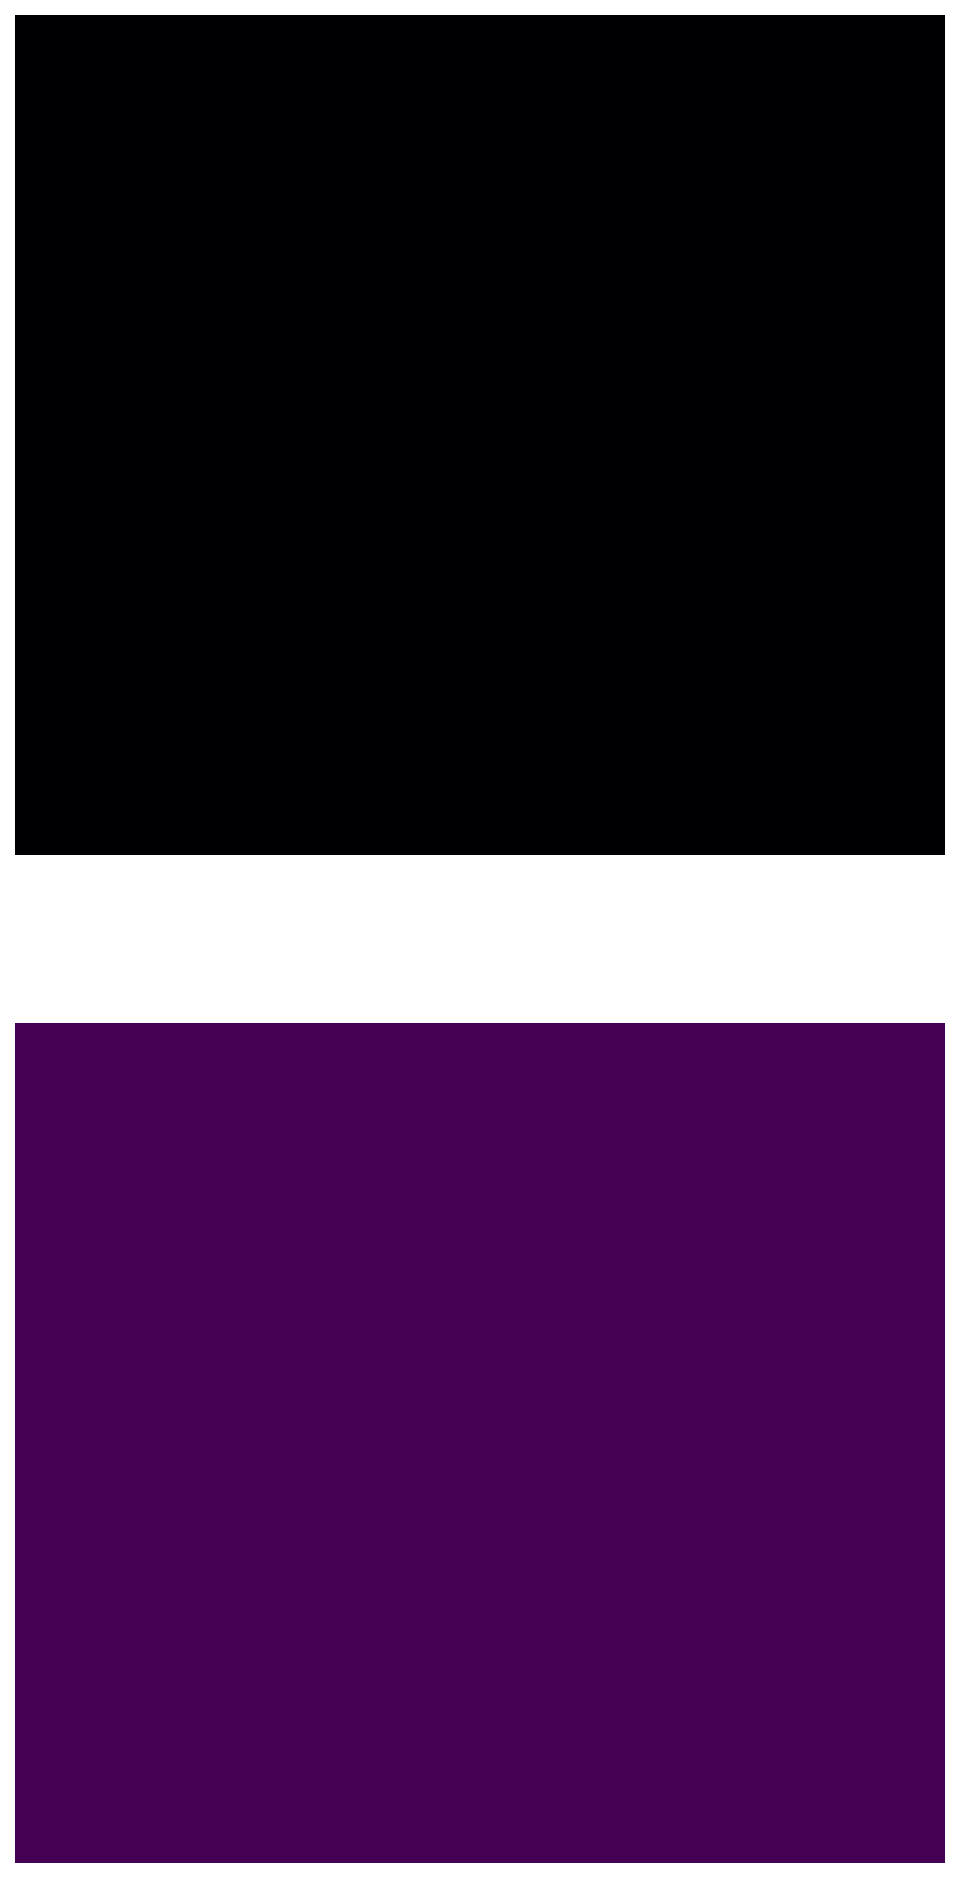

In [7]:
IV = ImageVisualizer((2, 1), record = True, save_path="./visualization", figsize=(8, 16), cmaps = ['inferno', None, None])

prev_sim_t = 0
rendering_t = 0

for file_name in file_names:

    #μs to s convertion.
    sim_t = float(file_name[:-3]) / 1000000
    sim_dt = sim_t - prev_sim_t
    
    file_path = os.path.join(folder_path, file_name)
    cell = torch.load(file_path)
    
    RT.update(cell, sim_dt, params['DX'], params['DY'], params['DZ'])
    SOOT.update(cell, sim_dt, params['DX'], params['DY'], params['DZ'])

    IV.update([RT.get_image(), SOOT.get_image()], sim_t)
    IV.set_title(f"{sim_t * 1000}ms")
    
    prev_sim_t = sim_t

In [ ]:
IV.close(PB_speed=0.1)